<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/Random%20Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape:
(20640, 9)

Feature Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Training Data: (16512, 8)
Testing Data: (4128, 8)

      RANDOM FOREST RESULTS
R² Score: 0.800365851772264
R² Score Percentage: 80.04 %
RMSE: 0.5115


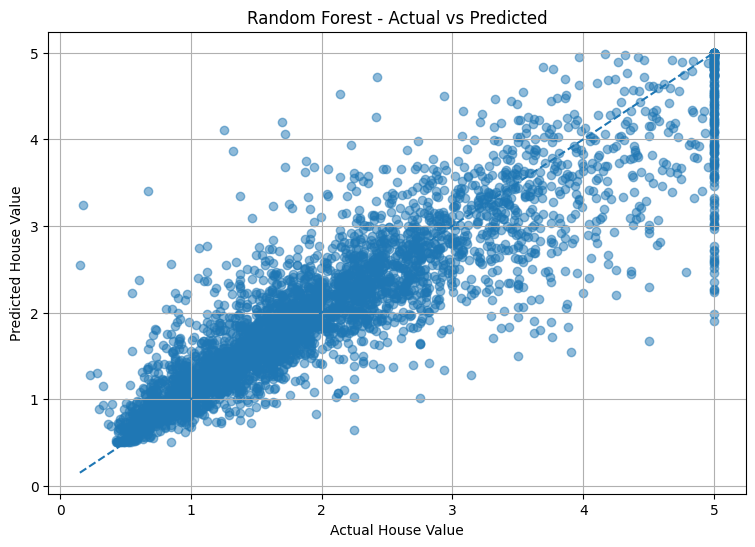

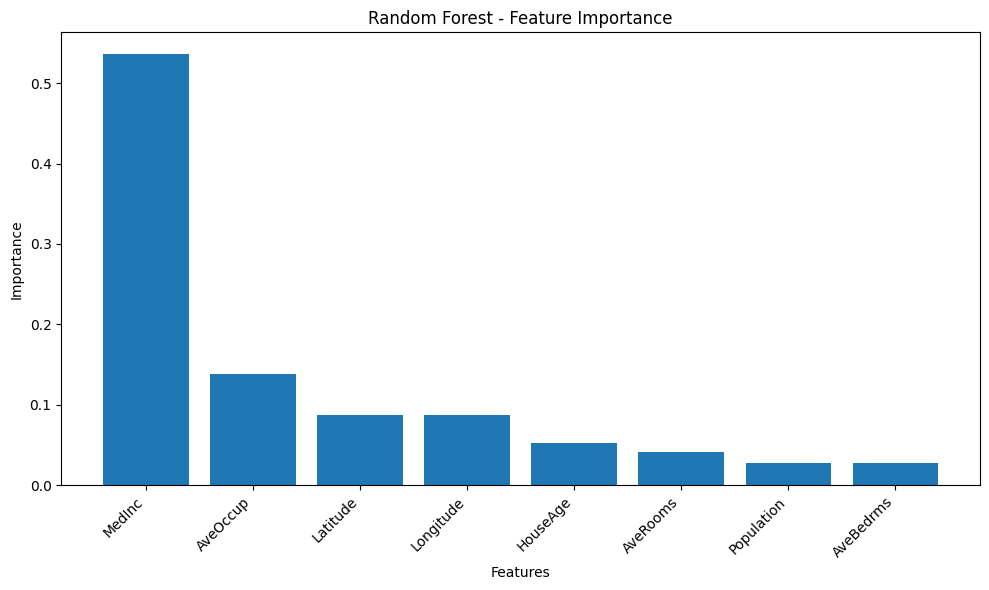

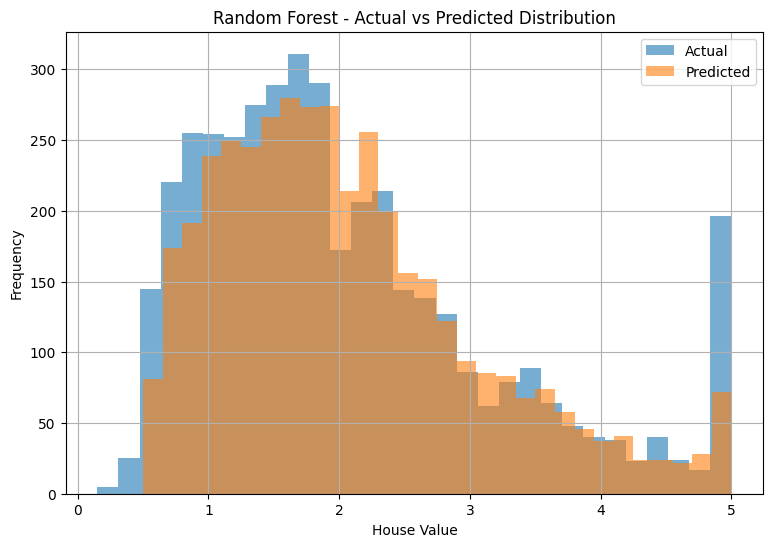


           FINAL RESULT
Random Forest R² Score = 0.8004
Random Forest R² Percentage = 80.04%
RMSE = 0.5115

Graphs Generated:
1. Actual vs Predicted Values
2. Feature Importance
3. Actual vs Predicted Distribution


In [4]:
# ============================================================
# RANDOM FOREST - CALIFORNIA HOUSING DATASET
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# ------------------------------------------------------------
# 2. LOAD CALIFORNIA HOUSING DATASET
# ------------------------------------------------------------

housing = fetch_california_housing()

X = housing.data
y = housing.target

# Convert to DataFrame
df = pd.DataFrame(
    X,
    columns=housing.feature_names
)

df["MedHouseVal"] = y

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nFeature Names:")
print(housing.feature_names)


# ------------------------------------------------------------
# 3. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(
    "MedHouseVal",
    axis=1
)

y = df["MedHouseVal"]


# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ------------------------------------------------------------
# 5. CREATE RANDOM FOREST MODEL
# ------------------------------------------------------------

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 6. TRAIN MODEL
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 7. PREDICTION
# ------------------------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------------------------
# 8. CALCULATE PERFORMANCE
# ------------------------------------------------------------

r2 = r2_score(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5


print("\n======================================")
print("      RANDOM FOREST RESULTS")
print("======================================")

print(
    "R² Score:",
    r2
)

print(
    "R² Score Percentage:",
    round(r2 * 100, 2),
    "%"
)

print(
    "RMSE:",
    round(rmse, 4)
)


# ============================================================
# GRAPH 1 - ACTUAL VS PREDICTED VALUES
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel(
    "Actual House Value"
)

plt.ylabel(
    "Predicted House Value"
)

plt.title(
    "Random Forest - Actual vs Predicted"
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.grid(True)

plt.show()


# ============================================================
# GRAPH 2 - FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)


plt.figure(figsize=(10, 6))

plt.bar(
    feature_importance.index,
    feature_importance.values
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Importance"
)

plt.title(
    "Random Forest - Feature Importance"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 3 - PREDICTION DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

plt.hist(
    y_test,
    bins=30,
    alpha=0.6,
    label="Actual"
)

plt.hist(
    y_pred,
    bins=30,
    alpha=0.6,
    label="Predicted"
)

plt.xlabel(
    "House Value"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Random Forest - Actual vs Predicted Distribution"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# FINAL RESULT
# ============================================================

print("\n======================================")
print("           FINAL RESULT")
print("======================================")

print(
    f"Random Forest R² Score = {r2:.4f}"
)

print(
    f"Random Forest R² Percentage = {r2 * 100:.2f}%"
)

print(
    f"RMSE = {rmse:.4f}"
)

print("\nGraphs Generated:")

print("1. Actual vs Predicted Values")
print("2. Feature Importance")
print("3. Actual vs Predicted Distribution")